# Scelta delle rotazioni negli ansatz PMA - analisi completa

**Obiettivo.** Quando si estende il PMA del dimero a piu' parametri con rotazioni reali che rompono la
conservazione di $M$, dove vanno messe le rotazioni: su **un solo** qubit o su **entrambi**? E con
parametri **condivisi** o **indipendenti**? Rispondo con derivazioni, disegni dei circuiti e
verifiche numeriche, isolando cosa aggiunge davvero espressivita' e cosa e' solo ridondanza.

**Contesto.** Dimero di Heisenberg isotropo con campo e termine DM (forma $XZ-ZX$, reale, che rompe
$M$):
$$H = J\,(X_1X_2+Y_1Y_2+Z_1Z_2) + b\,(Z_1+Z_2) + D\,(X_1Z_2-Z_1X_2),\qquad J=1.$$
Il ground state resta **reale**, quindi bastano rotazioni $R_y$.

**Risultato in una riga.** La rottura di $M$ utile richiede **due gradi di liberta' reali indipendenti**
(uno per il settore $M=+1$, uno per $M=-1$): una rotazione a **parametro condiviso** ne fornisce uno
solo e fallisce; servono rotazioni **indipendenti** sui due qubit (oppure una singola rotazione su uno
stato gia' entangled).

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator
from IPython.display import display

# --- fix del warning "default.json not found": si passa uno stile ESISTENTE esplicito ---
# (le versioni recenti di Qiskit non includono piu' default.json; iqp/textbook/clifford ci sono)
warnings.filterwarnings("ignore", message=".*default.json.*")   # cintura di sicurezza
def draw(qc):
    return qc.draw("mpl", style="iqp")

def hamiltonian(b, J=1.0, D=0.0):
    return SparsePauliOp.from_list([("XX",J),("YY",J),("ZZ",J),
                                    ("ZI",b),("IZ",b),("XZ",D),("ZX",-D)])
def exact_ground(b, J=1.0, D=0.0):
    w, v = np.linalg.eigh(hamiltonian(b, J, D).to_matrix()); return w, v
def ground_fidelity(psi, w, v, tol=1e-6):
    idx = np.where(np.abs(w - w[0]) < tol)[0]
    return float(sum(np.abs(np.vdot(v[:, i], psi))**2 for i in idx))
def vqe_multistart(anz, H, w, v, R=6, seed=1, maxiter=300):
    rng = np.random.default_rng(seed); n = anz.num_parameters; best = (np.inf, None)
    for _ in range(R):
        x0 = rng.uniform(0, 2*np.pi, n)
        f = lambda x: float(np.real(Statevector(anz.assign_parameters(x)).expectation_value(H)))
        r = minimize(f, x0, method="COBYLA", options={"maxiter": maxiter})
        if r.fun < best[0]: best = (r.fun, r.x)
    return ground_fidelity(Statevector(anz.assign_parameters(best[1])).data, w, v)
print("ok")

ok


## 1. I blocchi costitutivi: cosa sono e perche' si usano

### Blocco $M$-conservante
$M=\sum_i s_i^z = \tfrac12(Z_1+Z_2)$ e' la proiezione totale dello spin lungo $z$ (in pratica conta
quanti qubit sono a $∣1\rangle$). Un gate e' **$M$-conservante** se commuta con l'operatore $S_z$: non
sposta ampiezza fra settori a $M$ diverso. I quattro stati a 2 qubit si dividono in settori:

| settore | stati | $M$ |
|---|---|---|
| $M=+1$ | $∣00\rangle$ | $+1$ |
| $M=0$ | $∣01\rangle,\ ∣10\rangle$ | $0$ |
| $M=-1$ | $∣11\rangle$ | $-1$ |

**Perche' si usano.** Il PMA di Crippa et al. e' costruito **sulle simmetrie** del problema. A campo
basso il ground state del dimero e' il **singoletto** $(∣01\rangle-∣10\rangle)/\sqrt2$, che vive tutto
nel settore $M=0$. Un blocco $M$-conservante esplora *esattamente e solo* quel settore: raggiunge il
singoletto con il minimo numero di parametri, senza sprecare gradi di liberta' su stati irrilevanti.

### Blocco di Givens
Il **blocco di Givens** e' lo specifico gate $M$-conservante a 2 qubit che **ruota dentro il settore
$M=0$**, cioe' nel piano $\{∣01\rangle,∣10\rangle\}$, lasciando fermi $∣00\rangle$ e $∣11\rangle$:
$$G(\varphi)=\begin{pmatrix}1&&&\\&\cos\varphi&-\sin\varphi&\\&\sin\varphi&\cos\varphi&\\&&&1\end{pmatrix}.$$
E' una rotazione **ortogonale reale** (niente fasi complesse): il mattone naturale per stati reali nel
settore $M=0$. Lo realizzo **senza gate di Givens dedicati**, con soli $R_y$, Hadamard e CZ - lo
chiamo blocco **RBS** (reconfigurable beam splitter):
$$\mathrm{RBS}(\varphi) = (H\otimes H)\,\mathrm{CZ}\,\big(R_y(\varphi)_{q_0}\otimes R_y(-\varphi)_{q_1}\big)\,\mathrm{CZ}\,(H\otimes H).$$
Self-test (deve coincidere con $G(\varphi)$ a precisione macchina):

phi=+0.30   max|RBS - G| = 4.4e-16
phi=-0.70   max|RBS - G| = 4.4e-16
phi=+1.10   max|RBS - G| = 4.4e-16

Circuito del blocco RBS = G(0.5):


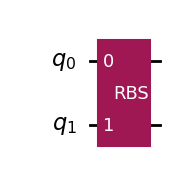

In [2]:
def rbs_block(qc, phi, q0=0, q1=1):
    """Blocco M-conservante RBS, disegnato come un unico box etichettato "RBS"
    (racchiude H-CZ-Ry-Ry-CZ-H, cosi' e' visivamente distinguibile nei circuiti)."""
    sub = QuantumCircuit(2, name="RBS")
    sub.h(0); sub.h(1); sub.cz(0, 1)
    sub.ry(phi, 0); sub.ry(-phi, 1)
    sub.cz(0, 1); sub.h(0); sub.h(1)
    qc.append(sub.to_gate(label="RBS"), [q0, q1])

def givens_target(phi):
    c, s = np.cos(phi), np.sin(phi); G = np.eye(4, dtype=complex)
    G[1,1]=c; G[1,2]=-s; G[2,1]=s; G[2,2]=c; return G
for phi in [0.3, -0.7, 1.1]:
    qc = QuantumCircuit(2); rbs_block(qc, phi)
    print(f"phi={phi:+.2f}   max|RBS - G| = {np.max(np.abs(Operator(qc).data - givens_target(phi))):.1e}")

qc = QuantumCircuit(2, name="RBS"); rbs_block(qc, 0.5)
print("\nCircuito del blocco RBS = G(0.5):")
draw(qc)

## 2. La preparazione dello stato di input

Prima delle rotazioni che rompono la simmetria, tutti i circuiti PMA preparano un **riferimento nel
settore $M=0$**. La preparazione ha due passi:

1. **$X$ sul qubit 1**: $∣00\rangle \xrightarrow{X_1} ∣01\rangle$. Porta dal vuoto al settore $M=0$
   (un solo qubit eccitato). E' uno stato prodotto, *non* ancora il singoletto.
2. **primo blocco RBS $G(\theta)$**: ruota dentro $M=0$. Per l'angolo giusto produce il **singoletto**.

Verifico che $G(+\pi/4)\,∣01\rangle$ e' esattamente il singoletto $(∣01\rangle-∣10\rangle)/\sqrt2$:

Passo 1 - riferimento M=0:


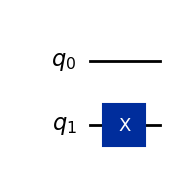

stato dopo X(q1): [0.+0.j 0.+0.j 1.+0.j 0.+0.j]  = |01>

Passo 2 - X(q1) + RBS(+pi/4):


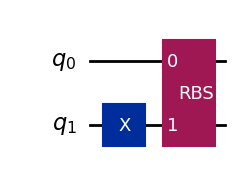

stato ottenuto: [ 0.   +0.j -0.707+0.j  0.707+0.j -0.   +0.j]
singoletto atteso: [ 0.    -0.707  0.707  0.   ]
fidelity col singoletto: 1.0


In [3]:
# passo 1: X su q1 -> |01>
prep = QuantumCircuit(2, name="prep |01>"); prep.x(1)
print("Passo 1 - riferimento M=0:")
fig = draw(prep); display(fig); plt.close(fig)
print("stato dopo X(q1):", np.round(Statevector(prep).data, 3), " = |01>\n")

# passo 2: X + RBS(-pi/4) -> singoletto
singlet_circ = QuantumCircuit(2, name="prep singoletto"); singlet_circ.x(1)
rbs_block(singlet_circ, np.pi/4)
psi = Statevector(singlet_circ).data
singlet = np.array([0, -1, 1, 0])/np.sqrt(2)   # (|01>-|10>) in ordinamento little-endian di Qiskit
print("Passo 2 - X(q1) + RBS(+pi/4):")
fig = draw(singlet_circ); display(fig); plt.close(fig)
print("stato ottenuto:", np.round(psi, 3))
print("singoletto atteso:", np.round(singlet, 3))
print("fidelity col singoletto:", round(abs(np.vdot(singlet, psi))**2, 6))

Quindi la "preparazione dello stato di input" e' $X_1$ (riferimento $M=0$) seguita dal primo blocco
RBS variazionale: a $\theta=+\pi/4$ e' il singoletto, ad altri angoli percorre tutto il settore $M=0$.
Nei circuiti PMA questo primo blocco e' gia' parametrico (il suo angolo e' ottimizzato dal VQE), quindi
non fisso $-\pi/4$: lascio che sia il VQE a scegliere il punto giusto del settore $M=0$.

## 3. La domanda

Il riferimento $M=0$ da solo non basta a $D\neq0$: il termine DM spinge il ground state fuori dal
settore $M=0$, verso $∣00\rangle$ e $∣11\rangle$. Servono rotazioni $R_y$ **reali** che aprano quei
settori. Tre modi possibili:

1. **1q** - $R_y$ su **un solo** qubit, 1 parametro per blocco;
2. **2q condiviso** - $R_y$ su **entrambi** ma con lo **stesso** parametro (a meno del segno);
3. **2q indipendente** - $R_y$ su **entrambi** con parametri **diversi**, 2 per blocco.

Li testo a $b/J=2$ (dove il PMA di base fallisce) e a $D$ crescente, e ne disegno i circuiti.

## 4. Esperimento A - rotazione su un solo qubit (sequenza 1, 2, 4, 6)

Alterna blocco RBS e $R_y$ sul solo $q_1$.

PMA-1q, 1 parametri:


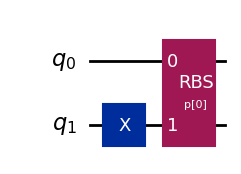

PMA-1q, 2 parametri:


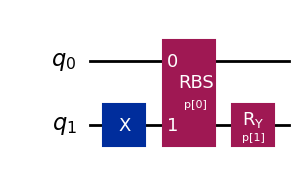

PMA-1q, 4 parametri:


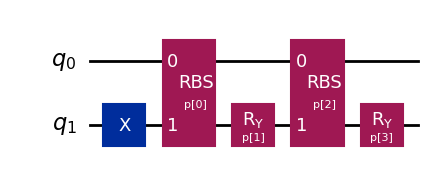

PMA-1q, 6 parametri:


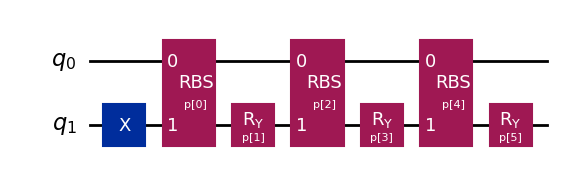

In [4]:
def pma_1q(nparam):
    p = ParameterVector("p", nparam); qc = QuantumCircuit(2); qc.x(1); i = 0
    rbs_block(qc, p[i]); i += 1
    while i < nparam:
        qc.ry(p[i], 1); i += 1                 # rottura di M: un solo qubit
        if i < nparam: rbs_block(qc, p[i]); i += 1
    return qc

for n in [1, 2, 4, 6]:
    print(f"PMA-1q, {n} parametri:")
    fig = draw(pma_1q(n)); display(fig); plt.close(fig)

In [5]:
print("Fidelity (b/J=2):")
for D in [0.2, 0.5, 1.0]:
    w, v = exact_ground(2.0, D=D); H = hamiltonian(2.0, D=D)
    row = "  ".join(f"n={n}:F={vqe_multistart(pma_1q(n),H,w,v):.3f}" for n in [1,2,4,6])
    print(f"  D={D}:  {row}")

Fidelity (b/J=2):
  D=0.2:  n=1:F=0.508  n=2:F=0.580  n=4:F=1.000  n=6:F=1.000
  D=0.5:  n=1:F=0.518  n=2:F=0.701  n=4:F=1.000  n=6:F=1.000
  D=1.0:  n=1:F=0.531  n=2:F=0.860  n=4:F=1.000  n=6:F=1.000


**Esito.** Funziona: $\mathcal F=1$ da $n=4$ in poi. Basta ruotare **un** qubit perche' lo stato
e' gia' entangled dal blocco RBS precedente: la rotazione locale, agendo su uno stato correlato,
popola comunque i settori $M=\pm1$.

## 5. Esperimento B - parametro condiviso, stesso segno (fallisce)

$R_y(\varphi)$ con lo **stesso** $\varphi$ su $q_0$ e $q_1$.

PMA 2q condiviso, 4 parametri:


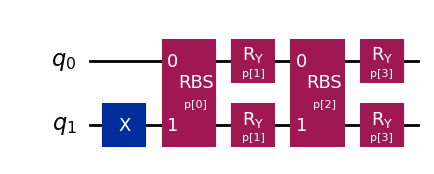

Fidelity (D=0.2, b/J=2): n=1:F=0.508  n=2:F=0.508  n=4:F=0.508  n=6:F=0.508


In [6]:
def pma_2q_shared(nparam):
    p = ParameterVector("p", nparam); qc = QuantumCircuit(2); qc.x(1); i = 0
    rbs_block(qc, p[i]); i += 1
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(p[i], 1); i += 1   # stesso parametro su entrambi
        if i < nparam: rbs_block(qc, p[i]); i += 1
    return qc

print("PMA 2q condiviso, 4 parametri:")
fig = draw(pma_2q_shared(4)); display(fig); plt.close(fig)

w, v = exact_ground(2.0, D=0.2); H = hamiltonian(2.0, D=0.2)
row = "  ".join(f"n={n}:F={vqe_multistart(pma_2q_shared(n),H,w,v):.3f}" for n in [1,2,4,6])
print("Fidelity (D=0.2, b/J=2):", row)

**Esito.** Fidelity **identica** per ogni $n$. Per escludere l'ottimizzatore, ottimizzo
**direttamente la fidelity** (non l'energia):

In [7]:
anz = pma_2q_shared(4); n = anz.num_parameters
w, v = exact_ground(2.0, D=0.2); psi_t = v[:, 0]
rng = np.random.default_rng(0); best = 0.0
for _ in range(20):
    x0 = rng.uniform(0, 2*np.pi, n)
    f = lambda x: -np.abs(np.vdot(psi_t, Statevector(anz.assign_parameters(x)).data))**2
    best = max(best, -minimize(f, x0, method="COBYLA", options={"maxiter":1000}).fun)
print(f"Fidelity massima raggiungibile (ottimizzata sullo stato): {best:.4f}")
print("-> < 1: limite STRUTTURALE, non dell'ottimizzatore.")

Fidelity massima raggiungibile (ottimizzata sullo stato): 0.7371
-> < 1: limite STRUTTURALE, non dell'ottimizzatore.


## 6. Esperimento C - parametro condiviso, segno opposto (satura)

PMA 2q condiviso (segno opposto), 4 parametri:


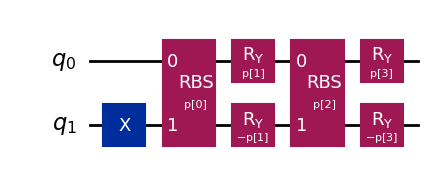

Fidelity (D=1.0, b/J=2): n=1:F=0.531  n=2:F=0.784  n=4:F=0.784  n=6:F=0.784


In [8]:
def pma_2q_oppo(nparam):
    p = ParameterVector("p", nparam); qc = QuantumCircuit(2); qc.x(1); i = 0
    rbs_block(qc, p[i]); i += 1
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(-p[i], 1); i += 1   # segno opposto, stesso |parametro|
        if i < nparam: rbs_block(qc, p[i]); i += 1
    return qc

print("PMA 2q condiviso (segno opposto), 4 parametri:")
fig = draw(pma_2q_oppo(4)); display(fig); plt.close(fig)

w, v = exact_ground(2.0, D=1.0); H = hamiltonian(2.0, D=1.0)
row = "  ".join(f"n={n}:F={vqe_multistart(pma_2q_oppo(n),H,w,v):.3f}" for n in [1,2,4,6])
print("Fidelity (D=1.0, b/J=2):", row)

**Esito.** Migliora rispetto a B ma **satura a $n=2$**: un solo grado di liberta' effettivo, solo
orientato diversamente.

## 7. Perche' il parametro condiviso fallisce (derivazione)

Dopo il blocco RBS lo stato e' $a\,∣01\rangle + b\,∣10\rangle$ (settore $M=0$). Applico $R_y$ con
$c=\cos\tfrac\varphi2,\ s=\sin\tfrac\varphi2$ e calcolo i coefficienti generati nei settori
$M=\pm1$ ($∣00\rangle,∣11\rangle$).

**Stesso segno** $R_y(\varphi)\otimes R_y(\varphi)$:
$$\langle 00∣\psi'\rangle = -cs\,(a+b),\qquad \langle 11∣\psi'\rangle = +cs\,(a+b).$$

**Segno opposto** $R_y(\varphi)\otimes R_y(-\varphi)$:
$$\langle 00∣\psi'\rangle = +cs\,(a-b),\qquad \langle 11∣\psi'\rangle = +cs\,(a-b).$$

In **entrambi** i casi $M=+1$ e $M=-1$ sono popolati da un'**unica** combinazione ($a+b$ oppure
$a-b$): **un solo grado di liberta' reale**. Non si possono riempire i due settori indipendentemente -
ecco perche' B e' piatto e C satura.

Con parametri **indipendenti** $R_y(\alpha)_{q_0}\otimes R_y(\beta)_{q_1}$, invece,
$\langle 00∣\psi'\rangle$ e $\langle 11∣\psi'\rangle$ diventano funzioni **distinte** di
$(\alpha,\beta)$: **due** gradi di liberta', uno per settore. Esattamente cio' che serve.

## 8. Esperimento D - rotazioni indipendenti su entrambi i qubit (sequenza 1, 3, 5, 7)

$R_y(\alpha)$ su $q_0$ e $R_y(\beta)$ su $q_1$ con $\alpha\neq\beta$: 2 parametri per coppia.

PMA-2q, 1 parametri:


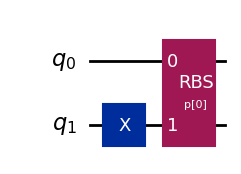

PMA-2q, 3 parametri:


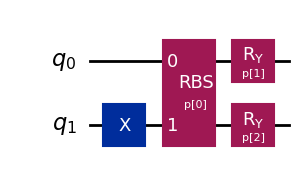

PMA-2q, 5 parametri:


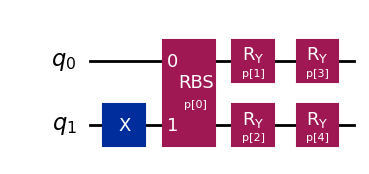

PMA-2q, 7 parametri:


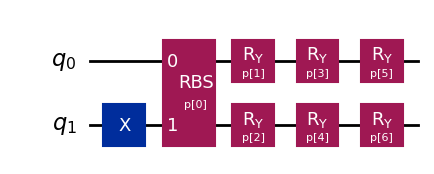

In [9]:
def pma_2q(nparam):
    p = ParameterVector("p", nparam); qc = QuantumCircuit(2); qc.x(1)
    rbs_block(qc, p[0]); i = 1
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(p[i+1], 1); i += 2   # coppia indipendente
    return qc

for n in [1, 3, 5, 7]:
    print(f"PMA-2q, {n} parametri:")
    fig = draw(pma_2q(n)); display(fig); plt.close(fig)

In [10]:
print("Fidelity (b/J=2):")
for D in [0.2, 0.5, 1.0]:
    w, v = exact_ground(2.0, D=D); H = hamiltonian(2.0, D=D)
    row = "  ".join(f"n={n}:F={vqe_multistart(pma_2q(n),H,w,v):.3f}" for n in [1,3,5,7])
    print(f"  D={D}:  {row}")

Fidelity (b/J=2):
  D=0.2:  n=1:F=0.508  n=3:F=1.000  n=5:F=1.000  n=7:F=1.000
  D=0.5:  n=1:F=0.518  n=3:F=1.000  n=5:F=1.000  n=7:F=1.000
  D=1.0:  n=1:F=0.531  n=3:F=1.000  n=5:F=1.000  n=7:F=1.000


**Esito.** $\mathcal F=1$ gia' a **$n=3$** (blocco RBS + una coppia indipendente = 3 gradi di
liberta' = tutto lo spazio reale a 2 qubit, $S^3$). $n=5,7$ confermano ma sono ridondanti: coppie
$R_y$ consecutive sullo stesso qubit si compongono, quindi i parametri extra sono gauge.

## 9. Confronto diretto e conclusioni

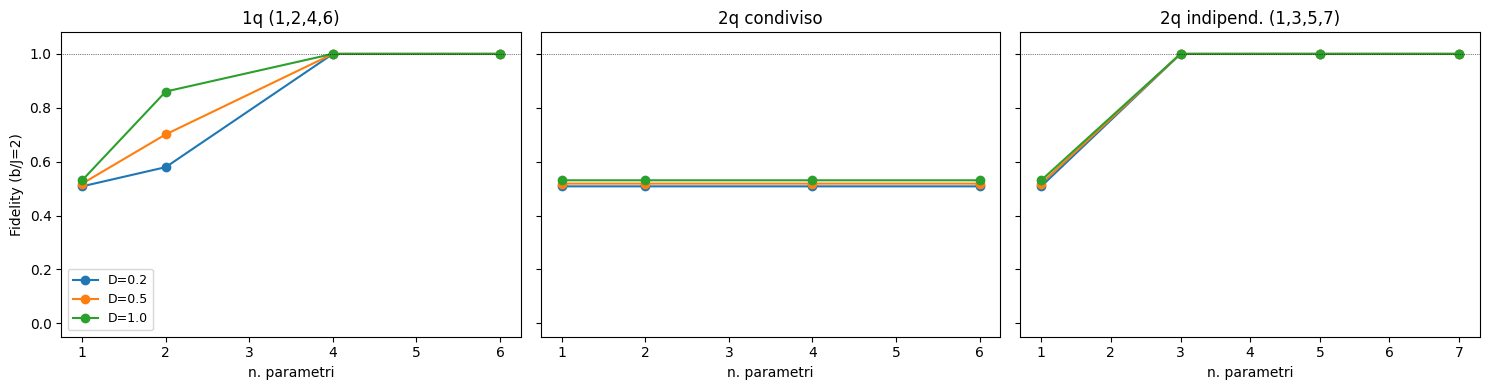

In [11]:
fams = {
    "1q (1,2,4,6)":            (pma_1q,        [1,2,4,6]),
    "2q condiviso":            (pma_2q_shared, [1,2,4,6]),
    "2q indipend. (1,3,5,7)":  (pma_2q,        [1,3,5,7]),
}
Dvals = [0.2, 0.5, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, (fn, seq)) in zip(axes, fams.items()):
    for D in Dvals:
        w, v = exact_ground(2.0, D=D); H = hamiltonian(2.0, D=D)
        F = [vqe_multistart(fn(n), H, w, v) for n in seq]
        ax.plot(seq, F, "o-", label=f"D={D}")
    ax.axhline(1.0, color="k", lw=0.5, ls=":")
    ax.set_title(label); ax.set_xlabel("n. parametri"); ax.set_ylim(-0.05, 1.08)
axes[0].set_ylabel("Fidelity (b/J=2)"); axes[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

### Conclusioni

| strategia | rotazioni | param/blocco | sequenza | esito |
|---|---|---|---|---|
| **1q** | un solo qubit | 1 | 1, 2, 4, 6 | $\mathcal F=1$ da $n=4$ |
| **2q condiviso** (stesso segno) | entrambi, stesso $\varphi$ | 1 | - | **fallisce** (max $\approx0.74$) |
| **2q condiviso** (segno opposto) | entrambi, $\pm\varphi$ | 1 | - | **satura** a $n=2$ |
| **2q indipendente** | entrambi, $\alpha\neq\beta$ | 2 | 1, 3, 5, 7 | $\mathcal F=1$ da $n=3$ |

**La lezione.** Rompere $M$ verso i settori $M=\pm1$ richiede **due gradi di liberta' reali
indipendenti**. Due vie economiche li forniscono: una rotazione su **un solo** qubit su uno stato
**gia' entangled** (via 1q, sequenza 1,2,4,6), oppure **due rotazioni indipendenti** su entrambi i
qubit (via 2q, sequenza 1,3,5,7). Non funziona il **parametro condiviso** su entrambi i qubit: e'
sotto-vincolato (un solo DOF, $a\pm b$). Entrambe le vie funzionanti raggiungono la stessa fisica; la
1q e' la piu' parsimoniosa, la 2q rende esplicita la simmetria fra i qubit al prezzo di un parametro
ridondante per blocco.